![image info](https://raw.githubusercontent.com/albahnsen/MIAD_ML_and_NLP/main/images/banner_1.png)

# Taller: Construcción e implementación de modelos Bagging, Random Forest y XGBoost

En este taller podrán poner en práctica sus conocimientos sobre la construcción e implementación de modelos de Bagging, Random Forest y XGBoost. El taller está constituido por 8 puntos, en los cuales deberan seguir las intrucciones de cada numeral para su desarrollo.

## Datos predicción precio de automóviles

En este taller se usará el conjunto de datos de Car Listings de Kaggle donde cada observación representa el precio de un automóvil teniendo en cuenta distintas variables como año, marca, modelo, entre otras. El objetivo es predecir el precio del automóvil. Para más detalles puede visitar el siguiente enlace: [datos](https://www.kaggle.com/jpayne/852k-used-car-listings).

In [2]:
import warnings
warnings.filterwarnings('ignore')

In [16]:
# Importación de librerías
%matplotlib inline
import pandas as pd

# Lectura de la información de archivo .csv
data = pd.read_csv('https://raw.githubusercontent.com/albahnsen/MIAD_ML_and_NLP/main/datasets/dataTrain_carListings.zip')

# Preprocesamiento de datos para el taller
data = data.loc[data['Model'].str.contains('Camry')].drop(['Make', 'State'], axis=1)
#Se crean columnas dummies que sean de tipo entero
data = data.join(pd.get_dummies(data['Model'], prefix='M', dtype=int))
data = data.drop(['Model'], axis=1)

# Visualización dataset
data.head()

,Price,Year,Mileage,M_Camry,M_Camry4dr,M_CamryBase,M_CamryL,M_CamryLE,M_CamrySE,M_CamryXLE
7,21995,2014,6480,0,0,0,1,0,0,0
11,13995,2014,39972,0,0,0,0,1,0,0
167,17941,2016,18989,0,0,0,0,0,1,0
225,12493,2014,51330,0,0,0,1,0,0,0
270,7994,2007,116065,0,1,0,0,0,0,0


In [10]:
# Librerias adicionales
import numpy as np
from sklearn import metrics
import matplotlib.pyplot as plt
from xgboost import XGBRegressor
from IPython.display import Markdown, display
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestRegressor, BaggingRegressor

In [6]:
display(Markdown(f"""### Datos iniciales:
                 \n Los datos cargados originalmente se componen de {data.shape[0]} filas, cada una representa una observación y {data.shape[1]} columnas, cada columna representa una variable."""))

# Análisis Valores Nulos\n
display(Markdown(f""" ### Análisis Valores Nulos:
    \n El dataset resultante tiene {data.isnull().sum().sum()} valores nulos."""))

### Datos iniciales:
                 
 Los datos cargados originalmente se componen de 10495 filas, cada una representa una observación y 10 columnas, cada columna representa una variable.

 ### Análisis Valores Nulos:
    
 El dataset resultante tiene 0 valores nulos.

In [7]:
# Separación de variables predictoras (X) y variable de interés (y)
y = data['Price']
X = data.drop(['Price'], axis=1)

In [8]:
# Separación de datos en set de entrenamiento y test
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

### Punto 1 - Árbol de decisión manual

En la celda 1 creen un árbol de decisión **manualmente**  que considere los set de entrenamiento y test definidos anteriormente y presenten el RMSE y MAE del modelo en el set de test.

In [15]:
# Celda 1

# Definición de la función que calcula el mse
def mse(y):
    if y.shape[0] == 0:
        return 0
    else:
        #Se usa la varianza para poder decir que tan parecidos son los números entre sí
        return y.var()
    
# Definición de la función mse para calular la ganancia de una variable predictora j dado el punto de corte k
def mse_impurity(X_col, y, split):
    
    filter_l = X_col < split
    y_l = y.loc[filter_l]
    y_r = y.loc[~filter_l]
    
    n_l = y_l.shape[0]
    n_r = y_r.shape[0]
    
    mse_y = mse(y)
    mse_l = mse(y_l)
    mse_r = mse(y_r)
    
    gain = mse_y - (n_l / (n_l + n_r) * mse_l + n_r / (n_l + n_r) * mse_r)
    
    return gain

# Definición de la función best_split para calcular cuál es la mejor variable y punto de cortepara hacer la bifurcación del árbol
def best_split(X, y, num_pct=10):
    features = range(X.shape[1])
    best_split = [0, 0, 0]  # j, split, gain
    
    # Para todas las varibles 
    for j in features:
        
        splits = np.percentile(X.iloc[:, j], np.arange(0, 100, 100.0 / (num_pct+1)).tolist())
        splits = np.unique(splits)[1:]
        
        # Para cada partición
        for split in splits:
            gain = mse_impurity(X.iloc[:, j], y, split)
                        
            if gain > best_split[2]:
                best_split = [j, split, gain]
    
    return best_split

# Definición de la función tree_grow para hacer un crecimiento recursivo del árbol
def tree_grow(X, y, level=0, min_gain=0.001, max_depth=None, num_pct=10):
    
    # Si solo es una observación
    if X.shape[0] == 1:
        return dict(y_pred=y.iloc[:1].values[0], y_prob=0.5, level=level, split=-1, n_samples=1, gain=0)
    
    # Calcular la mejor división
    j, split, gain = best_split(X, y, num_pct)
    
    # Guardar el árbol y estimar la predicción
    y_pred = y.mean() 
    
    tree = dict(y_pred=y_pred, level=level, split=-1, n_samples=X.shape[0], gain=gain)
    # Revisar el criterio de parada 
    if gain < min_gain:
        return tree
    if max_depth is not None:
        if level >= max_depth:
            return tree   
    
    # Continuar creando la partición
    filter_l = X.iloc[:, j] < split
    X_l, y_l = X.loc[filter_l], y.loc[filter_l]
    X_r, y_r = X.loc[~filter_l], y.loc[~filter_l]
    tree['split'] = [j, split]

    # Siguiente iteración para cada partición
    
    tree['sl'] = tree_grow(X_l, y_l, level + 1, min_gain=min_gain, max_depth=max_depth, num_pct=num_pct)
    tree['sr'] = tree_grow(X_r, y_r, level + 1, min_gain=min_gain, max_depth=max_depth, num_pct=num_pct)
    
    return tree

# Definición de la función tree_predict para hacer predicciones según las variables 'X' y el árbol 'tree'
def tree_predict(X, tree):
    predicted = np.ones(X.shape[0])

    # Revisar si es el nodo final
    if tree['split'] == -1:
        predicted = predicted * tree['y_pred']
    else:
        
        j, split = tree['split']
        filter_l = (X.iloc[:, j] < split)
        X_l = X.loc[filter_l]
        X_r = X.loc[~filter_l]

        if X_l.shape[0] == 0:  # Si el nodo izquierdo está vacio solo continua con el derecho 
            predicted[~filter_l] = tree_predict(X_r, tree['sr'])
        elif X_r.shape[0] == 0:  #  Si el nodo derecho está vacio solo continua con el izquierdo
            predicted[filter_l] = tree_predict(X_l, tree['sl'])
        else:
            predicted[filter_l] = tree_predict(X_l, tree['sl'])
            predicted[~filter_l] = tree_predict(X_r, tree['sr'])

    return predicted

Para poder hacer un arbol de decisión manual que de el mejor resultado posible, se procede a iterar sobre un rango para cambiar la profundidad máxima.

Adicionalmente, para poder ver le impacto del cambio del profundidad en las métricas de evaluación, se procede a gráficar el resultado obtenido.
                 
 Por otro lado, se gráfica también el precio real vs el precio predicho para las primeras 1000 observaciones de test

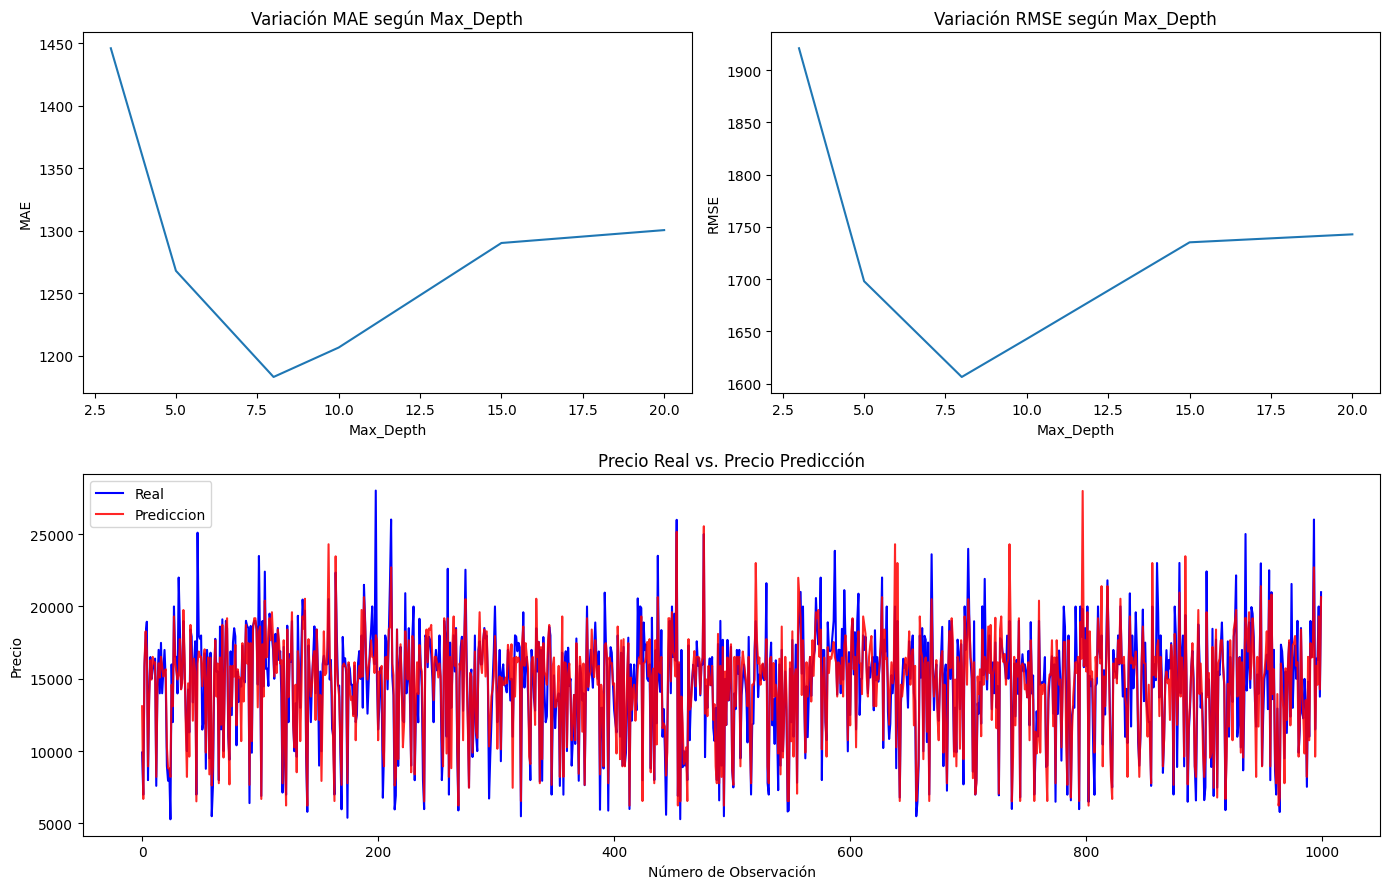

Finalmente, se puede ver que el modelo resultante, usa una ***profundidad de 8*** nodos y cuenta con un ***RMSE de 1606.2958*** y un ***MAE de 
                 1182.8332***, resultado de predecir sobre los datos de test establecidos.

                 
 Se puede decir que el error promedio del modelo al predecir el precio de los carros es de 1.182 USD. Por otro lado, se tiene un error cuadrado tipico de 1.606 USD, por 
                    lo que podemos decir que hay algunas veces en las que el modelo se equivoca mucho más que en otras. Si se quisiera mejorar el poder predictivo del modelo, se podrían
                    agregar algunos predictores adicionales al año y las millas recorridas.

                
 Lo anterior se peude confirmar dado el resulado que se observa en la gráfica, en donde se ve que la predicción no alcanza al valor de ciertos 'picos' y que para otros 
                   casos ocurre lo contrario, en donde el valor predicho es mucho mayor al real. Adicional, este comportamiento se presenta más frecuentemente para precios mayores a 
                   15.000 USD.

In [41]:
display(Markdown(f"""Para poder hacer un arbol de decisión manual que de el mejor resultado posible, se procede a iterar sobre un rango para cambiar la profundidad máxima."""))

# Creación de lista de valores para iterar sobre diferentes valores de max_depth
estimator_range = [3, 5, 8, 10, 15, 20]

# Definición de lista para almacenar las métrcias (MAE y RMSE) para cada valor de max_depth
metrics_mae = []
metrics_rmse = []
trees_list = []
y_pred_list = []

for estimator in estimator_range:
    tree = tree_grow(X_train, y_train, level=0, min_gain=0.001, max_depth=estimator, num_pct=10)
    y_pred = tree_predict(X_test, tree)
    mae_calculated = metrics.mean_absolute_error(y_test, y_pred)
    mse_calculated = metrics.mean_squared_error(y_test, y_pred)
    rmse_calculated = np.sqrt(mse_calculated)
    metrics_rmse.append(rmse_calculated)
    metrics_mae.append(mae_calculated)
    y_pred_list.append(y_pred)
    trees_list.append(tree)

#Se busca la posición del valor mínimo encontrado dada la iteración sobre la profundidad
best_idx = np.argmin(metrics_rmse) 

#e extraen los mejores valores resultantes de la iteración
best_depth = estimator_range[best_idx]
best_rmse = metrics_rmse[best_idx]
best_pred = y_pred_list[best_idx] 
best_mae = metrics_mae[best_idx]
best_tree = trees_list[best_idx] 

display(Markdown(f"""Adicionalmente, para poder ver le impacto del cambio del profundidad en las métricas de evaluación, se procede a gráficar el resultado obtenido.
                 \n Por otro lado, se gráfica también el precio real vs el precio predicho para las primeras 1000 observaciones de test"""))

plt.figure(figsize=(14, 9))
plt.subplot(2, 2, 1)
plt.plot(estimator_range, metrics_mae)
plt.title('Variación MAE según Max_Depth')
plt.xlabel('Max_Depth')
plt.ylabel('MAE')

plt.subplot(2, 2, 2)
plt.plot(estimator_range, metrics_rmse)
plt.title('Variación RMSE según Max_Depth')
plt.xlabel('Max_Depth')
plt.ylabel('RMSE')

plt.subplot(2, 1, 2)
plt.plot(y_test.values[:1000], color='blue', label='Real')
plt.plot(best_pred[:1000], color='red', label='Prediccion', alpha=0.85)
plt.title('Precio Real vs. Precio Predicción')
plt.xlabel('Número de Observación')
plt.ylabel('Precio')
plt.legend()

plt.tight_layout()
plt.show()

display(Markdown(f"""Finalmente, se puede ver que el modelo resultante, usa una ***profundidad de {best_depth}*** nodos y cuenta con un ***RMSE de {best_rmse:.4f}*** y un ***MAE de 
                 {best_mae:.4f}***, resultado de predecir sobre los datos de test establecidos.
                 
                 \n Se puede decir que el error promedio del modelo al predecir el precio de los carros es de 1.182 USD. Por otro lado, se tiene un error cuadrado tipico de 1.606 USD, por 
                    lo que podemos decir que hay algunas veces en las que el modelo se equivoca mucho más que en otras. Si se quisiera mejorar el poder predictivo del modelo, se podrían
                    agregar algunos predictores adicionales al año y las millas recorridas.
                   
                \n Lo anterior se peude confirmar dado el resulado que se observa en la gráfica, en donde se ve que la predicción no alcanza al valor de ciertos 'picos' y que para otros 
                   casos ocurre lo contrario, en donde el valor predicho es mucho mayor al real. Adicional, este comportamiento se presenta más frecuentemente para precios mayores a 
                   15.000 USD."""))


### Punto 2 - Bagging manual

En la celda 2 creen un modelo bagging **manualmente** con 10 árboles de regresión y comenten sobre el desempeño del modelo.

Se implementa un modelo de ***Bagging*** manual en donde se entrenan 10 arboles de decisión simples pero cada uno de ellos cuenta con muestras diferentes (incluyendo
                 la posibilidad de que las muestras cuenten con observaciones repetidas) y luego se promedia el resultado de los 10, lo cual genera mayor diversidad, dado que cada árbol
                 se entrena con carros diferentes. 

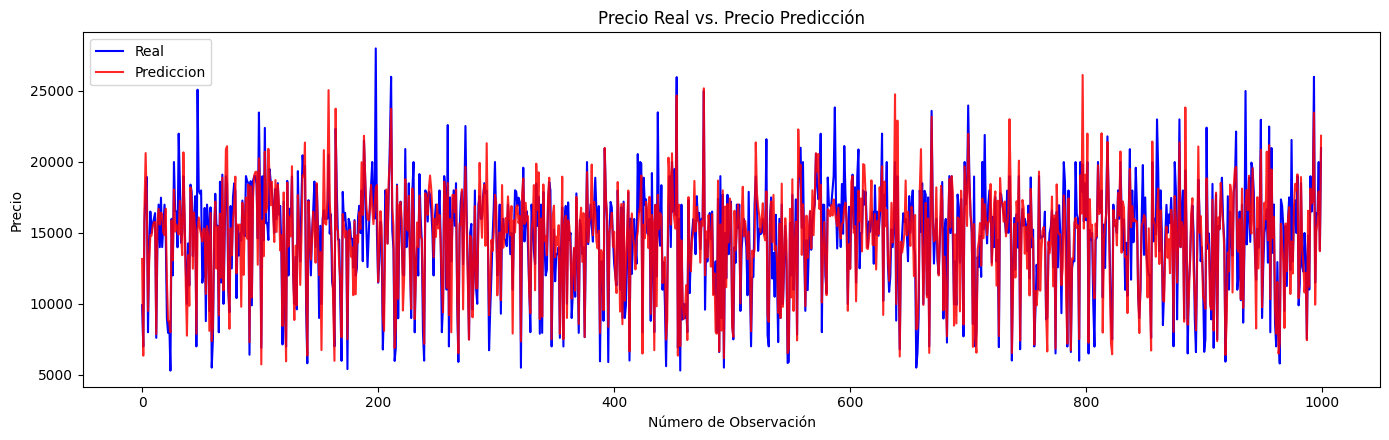

Finalmente, se tiene que el modelo resultante cuenta con un ***RMSE de 1802.5512*** y un ***MAE de 1350.3792***. Los cuales muestran que el modelo tiene 
                 un desempeño inferior al modelo implementado de árbol de decisión manual. Teniendo que el error promedio es de -167.5 USD menos y que el RMSE es de 
                 -196.3 USD menos, lo cual se puede ver representado en la gráfica de los resultados reales vs predichos para las primeras 1000 observaciones, en donde 
                 se ven que el desempeño es similar al anterior pero que para algunos 'picos' el resultado de la predicción es mayor o menor al resultado real, provocando que haya más 
                 diferencia entre los valores y aumenten los valores de las métricas.

In [50]:
# Celda 2

num_arboles = 10
predicciones = np.zeros((X_test.shape[0], num_arboles))

for i in range(num_arboles):
    #Generar indices aleatoios con el mismo número de observaciones
    muestra = np.random.choice(np.arange(X_train.shape[0]), size=X_train.shape[0], replace=True)

    #Se generan X y Y para los indices que se generaron
    X_muestra = X_train.iloc[muestra]
    Y_muestra = y_train.iloc[muestra]

    #Se entrena un arbol de decisión con las muestras
    modelo = DecisionTreeRegressor(random_state=i)
    modelo.fit(X_muestra, Y_muestra)
    predicciones[:,i] = modelo.predict(X_test)

y_pred_final_bagg_m = predicciones.mean(axis=1)
mae_bagg_m = metrics.mean_absolute_error(y_test, y_pred_final_bagg_m)
mse_bagg_m = metrics.mean_squared_error(y_test, y_pred_final_bagg_m)
rmse_bagg_m = np.sqrt(mse_bagg_m)

display(Markdown(f"""Se implementa un modelo de ***Bagging*** manual en donde se entrenan 10 arboles de decisión simples pero cada uno de ellos cuenta con muestras diferentes (incluyendo
                 la posibilidad de que las muestras cuenten con observaciones repetidas) y luego se promedia el resultado de los 10, lo cual genera mayor diversidad, dado que cada árbol
                 se entrena con carros diferentes. """))

#Gráfica
plt.figure(figsize=(14, 4.5))
plt.plot(y_test.values[:1000], color='blue', label='Real')
plt.plot(y_pred_final_bagg_m[:1000], color='red', label='Prediccion', alpha=0.85)
plt.title('Precio Real vs. Precio Predicción')
plt.xlabel('Número de Observación')
plt.ylabel('Precio')
plt.legend()
plt.tight_layout()
plt.show()

diff_mae_tree_vs_baggm = best_mae - mae_bagg_m
diff_rmse_tree_vs_baggm = best_rmse - rmse_bagg_m

display(Markdown(f"""Finalmente, se tiene que el modelo resultante cuenta con un ***RMSE de {rmse_bagg_m:.4f}*** y un ***MAE de {mae_bagg_m:.4f}***. Los cuales muestran que el modelo tiene 
                 un desempeño inferior al modelo implementado de árbol de decisión manual. Teniendo que el error promedio es de {diff_mae_tree_vs_baggm:.1f} USD menos y que el RMSE es de 
                 {diff_rmse_tree_vs_baggm:.1f} USD menos, lo cual se puede ver representado en la gráfica de los resultados reales vs predichos para las primeras 1000 observaciones, en donde 
                 se ven que el desempeño es similar al anterior pero que para algunos 'picos' el resultado de la predicción es mayor o menor al resultado real, provocando que haya más 
                 diferencia entre los valores y aumenten los valores de las métricas."""))

### Punto 3 - Bagging con librería

En la celda 3, con la librería sklearn, entrenen un modelo bagging con 10 árboles de regresión y el parámetro `max_features` del árbol de decisión igual a `log(n_features)` y comenten sobre el desempeño del modelo.

Se implementa un modelo de Bagging haciendo uso de la librería sklearn y estableciendo los valores de algunos parámetros como; profundidad máxima de 10 y ***max_features***
                 igual al $log2$ de la cantidad total de variables, limitando así la cantidad de información que cada árbol usar para poder predecir.

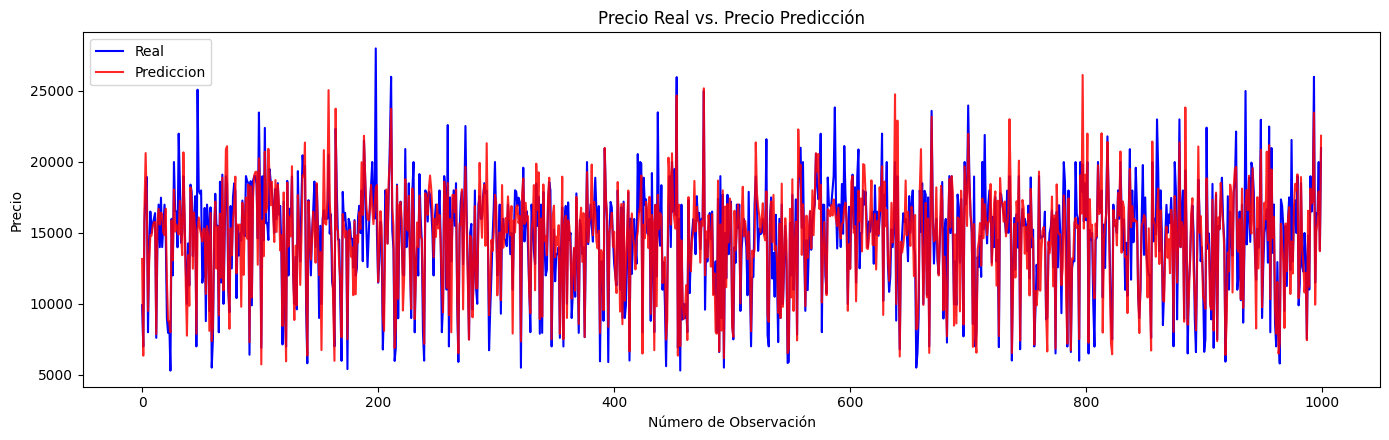

Después de hacer la implementación de un modelo bagging usando parametros específicos, se obtiene que el modelo resultante cuenta con un ***RMSE de 1802.5512*** 
                 y un ***MAE de 1350.3792***. Los cuales muestran que el modelo tiene un desempeño inferior a ambos modelos implementados anteriormente. Teniendo que el error promedio 
                 es de -167.5 USD menos y que el RMSE es de -196.3 USD menos, lo cual se puede ver representado en la gráfica de los resultados 
                 reales vs predichos para las primeras 1000 observaciones.

                 
 Adicionalmente, podemos decir que dados los datos disponibles, las estrategias de generar diversidad modificando las obrevaciones y columnas que cada arbol recibe, no
                 están generando una mejora en el poder predictivo, sino que por el contrario, están provocando que el modelo final se equivoque más cuando predice sobre observaciones 
                 nuevas.

In [51]:
# Celda 3
num_arboles = 10
max_features = int(np.log2(X_train.shape[1]))

bagging_model = BaggingRegressor(max_features=max_features, n_estimators=num_arboles, bootstrap=True, random_state=20)
bagging_model.fit(X_train,y_train)

y_pred_final_bagg = predicciones.mean(axis=1)
mae_bagg = metrics.mean_absolute_error(y_test, y_pred_final_bagg)
mse_bagg = metrics.mean_squared_error(y_test, y_pred_final_bagg)
rmse_bagg = np.sqrt(mse_bagg)

display(Markdown(f"""Se implementa un modelo de Bagging haciendo uso de la librería sklearn y estableciendo los valores de algunos parámetros como; profundidad máxima de 10 y ***max_features***
                 igual al $log2$ de la cantidad total de variables, limitando así la cantidad de información que cada árbol usar para poder predecir."""))

#Gráfica
plt.figure(figsize=(14, 4.5))
plt.plot(y_test.values[:1000], color='blue', label='Real')
plt.plot(y_pred_final_bagg[:1000], color='red', label='Prediccion', alpha=0.85)
plt.title('Precio Real vs. Precio Predicción')
plt.xlabel('Número de Observación')
plt.ylabel('Precio')
plt.legend()
plt.tight_layout()
plt.show()

diff_mae_tree_vs_bagg = best_mae - mae_bagg
diff_rmse_tree_vs_bagg = best_rmse - rmse_bagg

display(Markdown(f"""Después de hacer la implementación de un modelo bagging usando parametros específicos, se obtiene que el modelo resultante cuenta con un ***RMSE de {rmse_bagg_m:.4f}*** 
                 y un ***MAE de {mae_bagg_m:.4f}***. Los cuales muestran que el modelo tiene un desempeño inferior a ambos modelos implementados anteriormente. Teniendo que el error promedio 
                 es de {diff_mae_tree_vs_baggm:.1f} USD menos y que el RMSE es de {diff_rmse_tree_vs_baggm:.1f} USD menos, lo cual se puede ver representado en la gráfica de los resultados 
                 reales vs predichos para las primeras 1000 observaciones.
                 
                 \n Adicionalmente, podemos decir que dados los datos disponibles, las estrategias de generar diversidad modificando las obrevaciones y columnas que cada arbol recibe, no
                 están generando una mejora en el poder predictivo, sino que por el contrario, están provocando que el modelo final se equivoque más cuando predice sobre observaciones 
                 nuevas."""))

### Punto 4 - Random forest con librería

En la celda 4, usando la librería sklearn entrenen un modelo de Randon Forest para regresión  y comenten sobre el desempeño del modelo.

Se implementa un modelo Random Forest haciendo uso de la librería sklearn y no se hace modificación de los parámetros

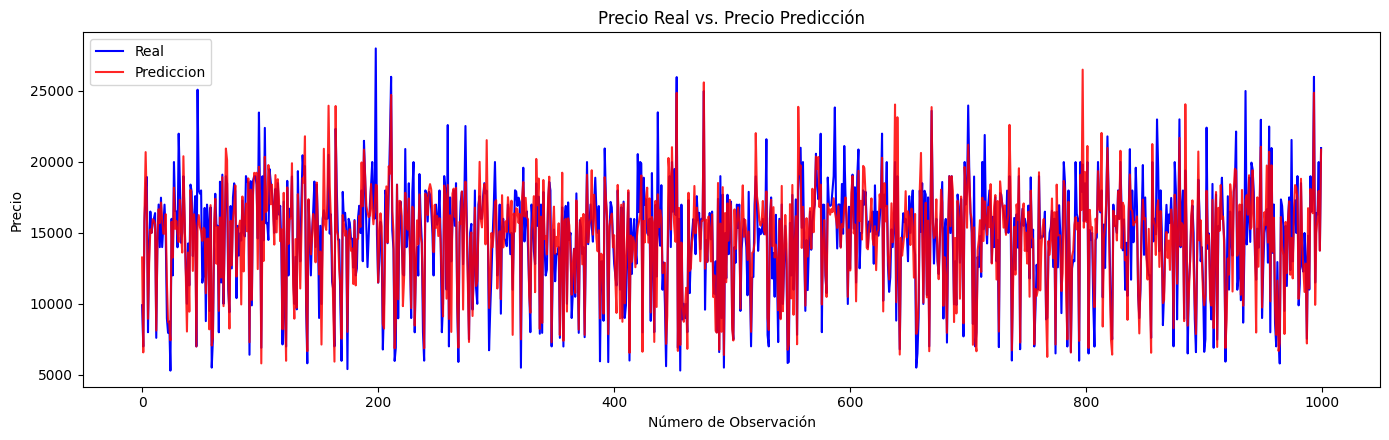

Se obtiene que el modelo resultante cuenta con un ***RMSE de 1755.2659*** y un ***MAE de 1308.3775***.

In [54]:
# Celda 4
clf_random = RandomForestRegressor(random_state=40)
clf_random.fit(X_train, y_train)

y_pred_random = clf_random.predict(X_test)
mae_random = metrics.mean_absolute_error(y_test, y_pred_random)
mse_random = metrics.mean_squared_error(y_test, y_pred_random)
rmse_random = np.sqrt(mse_random)

display(Markdown(f"""Se implementa un modelo Random Forest haciendo uso de la librería sklearn y no se hace modificación de los parámetros"""))

#Gráfica
plt.figure(figsize=(14, 4.5))
plt.plot(y_test.values[:1000], color='blue', label='Real')
plt.plot(y_pred_random[:1000], color='red', label='Prediccion', alpha=0.85)
plt.title('Precio Real vs. Precio Predicción')
plt.xlabel('Número de Observación')
plt.ylabel('Precio')
plt.legend()
plt.tight_layout()
plt.show()

display(Markdown(f"""Se obtiene que el modelo resultante cuenta con un ***RMSE de {rmse_random:.4f}*** y un ***MAE de {mae_random:.4f}***."""))

### Punto 5 - Calibración de parámetros Random forest

En la celda 5, calibren los parámetros max_depth, max_features y n_estimators del modelo de Randon Forest para regresión, comenten sobre el desempeño del modelo y describan cómo cada parámetro afecta el desempeño del modelo.

In [1]:
# Celda 5


### Punto 6 - XGBoost con librería

En la celda 6 implementen un modelo XGBoost de regresión con la librería sklearn y comenten sobre el desempeño del modelo.

Se implementa un modelo Xtreme Gradient Boosting haciendo uso de la librería sklearn y no se hace modificación de los parámetros

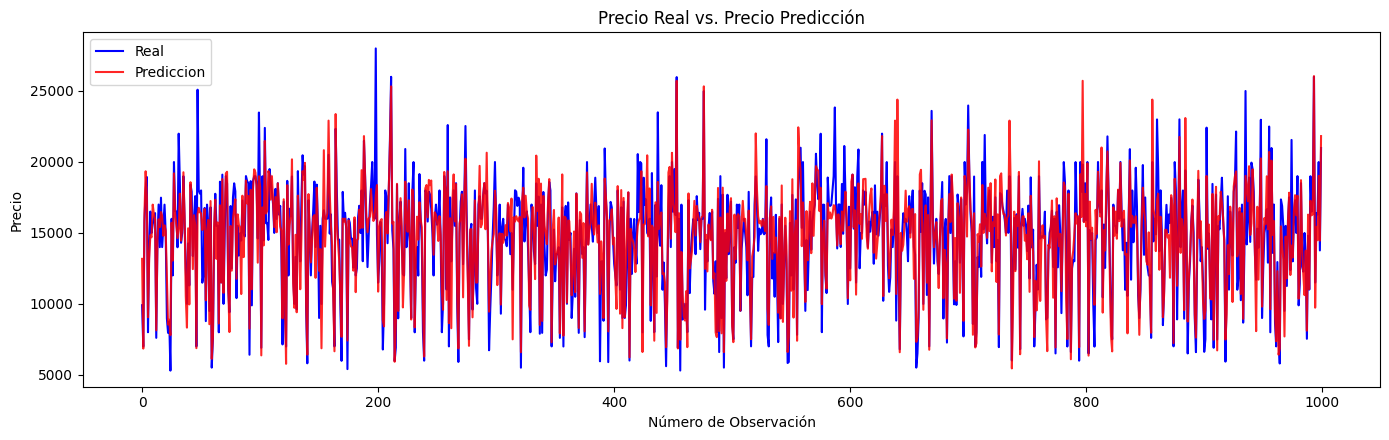

Se obtiene que el modelo resultante cuenta con un ***RMSE de 1605.2355*** y un ***MAE de 1185.2273***.

In [55]:
# Celda 6
clf = XGBRegressor(random_state=60)
clf.fit(X_train, y_train)

y_pred_xgb = clf.predict(X_test)
mae_xgb = metrics.mean_absolute_error(y_test, y_pred_xgb)
mse_xgb = metrics.mean_squared_error(y_test, y_pred_xgb)
rmse_xgb = np.sqrt(mse_xgb)

display(Markdown(f"""Se implementa un modelo Xtreme Gradient Boosting haciendo uso de la librería sklearn y no se hace modificación de los parámetros"""))

#Gráfica
plt.figure(figsize=(14, 4.5))
plt.plot(y_test.values[:1000], color='blue', label='Real')
plt.plot(y_pred_xgb[:1000], color='red', label='Prediccion', alpha=0.85)
plt.title('Precio Real vs. Precio Predicción')
plt.xlabel('Número de Observación')
plt.ylabel('Precio')
plt.legend()
plt.tight_layout()
plt.show()

display(Markdown(f"""Se obtiene que el modelo resultante cuenta con un ***RMSE de {rmse_xgb:.4f}*** y un ***MAE de {mae_xgb:.4f}***."""))

### Punto 7 - Calibración de parámetros XGBoost

En la celda 7 calibren los parámetros learning rate, gamma y colsample_bytree del modelo XGBoost para regresión, comenten sobre el desempeño del modelo y describan cómo cada parámetro afecta el desempeño del modelo.

In [ ]:
# Celda 7


### Punto 8 - Comparación y análisis de resultados
En la celda 8 comparen los resultados obtenidos de los diferentes modelos (random forest y XGBoost) y comenten las ventajas del mejor modelo y las desventajas del modelo con el menor desempeño.

In [ ]:
# Celda 8
